# Libraries for Neural Networks - PyTorch



In [1]:
# PyTorch is pre-installed — verify version
import torch
print('PyTorch version:', torch.__version__)


PyTorch version: 2.12.0


## Loading the dataset

In [2]:
torch.__version__


'2.12.0'

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import torch.nn as nn

In [4]:
breast = datasets.load_breast_cancer()

In [5]:
breast.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [6]:
breast.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
breast.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [8]:
breast.target_names

array(['malignant', 'benign'], dtype='<U9')

In [9]:
inputs = breast.data
inputs.shape

(569, 30)

In [10]:
outputs = breast.target
outputs.shape

(569,)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size = 0.25)

In [12]:
X_train.shape

(426, 30)

In [13]:
X_test.shape

(143, 30)

## Data transformation


In [14]:
type(X_train)

numpy.ndarray

In [15]:
X_train = torch.tensor(X_train, dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.float)

In [16]:
type(X_train)

torch.Tensor

In [17]:
dataset = torch.utils.data.TensorDataset(X_train, y_train)

In [18]:
type(dataset)

torch.utils.data.dataset.TensorDataset

In [19]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10)

## Neural network structure

In [20]:
(30 + 1) / 2

15.5

In [21]:
# 30 -> 16 -> 16 -> 1
network = nn.Sequential(nn.Linear(in_features=30, out_features=16),
                        nn.Sigmoid(),
                        nn.Linear(16, 16),
                        nn.Sigmoid(),
                        nn.Linear(16, 1),
                        nn.Sigmoid())

In [22]:
network.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)>

In [23]:
loss_function = nn.BCELoss()

In [24]:
optimizer = torch.optim.Adam(network.parameters(), lr = 0.001)

In [25]:
epochs = 100
for epoch in range(epochs):
  running_loss = 0.

  for data in train_loader:
    inputs, outputs = data
    optimizer.zero_grad()

    predictions = network.forward(inputs)
    # squeeze predictions from (batch,1) to (batch,) to match targets shape
    loss = loss_function(predictions.squeeze(), outputs)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  print('Epoch:', epoch + 1, ' loss:', running_loss / len(train_loader))


Epoch: 1  loss: 0.6503618234811828
Epoch: 2  loss: 0.6306583493254906
Epoch: 3  loss: 0.6178181531817414
Epoch: 4  loss: 0.6037826718286027
Epoch: 5  loss: 0.5801884843859562
Epoch: 6  loss: 0.5552917691164239
Epoch: 7  loss: 0.5281447823657546
Epoch: 8  loss: 0.4995638152887655
Epoch: 9  loss: 0.46693233556525654
Epoch: 10  loss: 0.43645985667095627
Epoch: 11  loss: 0.40253896283548934
Epoch: 12  loss: 0.3772589432638745
Epoch: 13  loss: 0.35723495240821396
Epoch: 14  loss: 0.3306181739236033
Epoch: 15  loss: 0.3152376631664675
Epoch: 16  loss: 0.3024875337994376
Epoch: 17  loss: 0.28723618492137554


Epoch: 18  loss: 0.27524355192517125
Epoch: 19  loss: 0.2765142529509788
Epoch: 20  loss: 0.2517095669064411
Epoch: 21  loss: 0.25058176541744276
Epoch: 22  loss: 0.24405703225801156
Epoch: 23  loss: 0.2559395124052846
Epoch: 24  loss: 0.23787162574224693
Epoch: 25  loss: 0.23617750562207643
Epoch: 26  loss: 0.23589981260687806
Epoch: 27  loss: 0.2402015054641768
Epoch: 28  loss: 0.22460713410793348
Epoch: 29  loss: 0.21723360282390616
Epoch: 30  loss: 0.21795626253236172
Epoch: 31  loss: 0.22130975274499073
Epoch: 32  loss: 0.229897020081448
Epoch: 33  loss: 0.22269678332431372


Epoch: 34  loss: 0.2448160955032637
Epoch: 35  loss: 0.21846614985965018
Epoch: 36  loss: 0.21941368948928144
Epoch: 37  loss: 0.2169112879349742
Epoch: 38  loss: 0.20049893986000572
Epoch: 39  loss: 0.23437231952367826
Epoch: 40  loss: 0.22808237850319507
Epoch: 41  loss: 0.2191123755345511
Epoch: 42  loss: 0.2111340141746887
Epoch: 43  loss: 0.20229321778860204
Epoch: 44  loss: 0.19913122144549392
Epoch: 45  loss: 0.19380125039538673
Epoch: 46  loss: 0.19472784358401632
Epoch: 47  loss: 0.20897232325271117
Epoch: 48  loss: 0.20109001581752023
Epoch: 49  loss: 0.1951011880625819
Epoch: 50  loss: 0.18708474128398783


Epoch: 51  loss: 0.1922562517832185
Epoch: 52  loss: 0.19790825650615748
Epoch: 53  loss: 0.19464076591958834
Epoch: 54  loss: 0.18501549071177495
Epoch: 55  loss: 0.1891751190170992
Epoch: 56  loss: 0.1830774006368809
Epoch: 57  loss: 0.19257783478255883
Epoch: 58  loss: 0.18967337295586287
Epoch: 59  loss: 0.17624925938976366
Epoch: 60  loss: 0.18514943621013052
Epoch: 61  loss: 0.19770373456006826
Epoch: 62  loss: 0.1999667691023544
Epoch: 63  loss: 0.1885436924044476
Epoch: 64  loss: 0.18229040637785612
Epoch: 65  loss: 0.18968731927317242
Epoch: 66  loss: 0.1818024665550437
Epoch: 67  loss: 0.18607150226138358


Epoch: 68  loss: 0.18649063930781776
Epoch: 69  loss: 0.18951021910233554
Epoch: 70  loss: 0.18596542877859848
Epoch: 71  loss: 0.2114663078168104
Epoch: 72  loss: 0.18611540762317735
Epoch: 73  loss: 0.18962377578366635
Epoch: 74  loss: 0.1775096928224314
Epoch: 75  loss: 0.17982266825992008
Epoch: 76  loss: 0.18808071462567463
Epoch: 77  loss: 0.1843468389192293
Epoch: 78  loss: 0.1888996189416841
Epoch: 79  loss: 0.18331123442324096
Epoch: 80  loss: 0.21142783436144508
Epoch: 81  loss: 0.18283347724828608
Epoch: 82  loss: 0.2063964319003876
Epoch: 83  loss: 0.1838104348889617
Epoch: 84  loss: 0.19052234922297473


Epoch: 85  loss: 0.19462803805376902
Epoch: 86  loss: 0.1949981823996749
Epoch: 87  loss: 0.19595559682090616
Epoch: 88  loss: 0.18765723770267742
Epoch: 89  loss: 0.20439320657575547
Epoch: 90  loss: 0.19513628064373204
Epoch: 91  loss: 0.19590682451894811
Epoch: 92  loss: 0.19299473656817925
Epoch: 93  loss: 0.18511568516666113
Epoch: 94  loss: 0.19242162844382746
Epoch: 95  loss: 0.1904135310675862
Epoch: 96  loss: 0.1887774305461451
Epoch: 97  loss: 0.2054491665994012
Epoch: 98  loss: 0.17925431947548723
Epoch: 99  loss: 0.2007910740063634
Epoch: 100  loss: 0.18854511423079773


## Evaluate

In [26]:
network.eval()

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

In [27]:
X_test.shape

(143, 30)

In [28]:
type(X_test)

numpy.ndarray

In [29]:
X_test = torch.tensor(X_test, dtype=torch.float)
type(X_test)

torch.Tensor

In [30]:
with torch.no_grad():
    predictions = network.forward(X_test)
predictions


tensor([[0.0133],
        [0.0133],
        [0.9879],
        [0.0716],
        [0.0133],
        [0.0133],
        [0.0133],
        [0.9880],
        [0.9614],
        [0.0133],
        [0.9845],
        [0.3458],
        [0.9798],
        [0.6422],
        [0.9641],
        [0.9876],
        [0.9880],
        [0.7065],
        [0.9512],
        [0.9815],
        [0.9552],
        [0.9874],
        [0.9796],
        [0.0840],
        [0.0135],
        [0.9841],
        [0.9876],
        [0.9880],
        [0.0133],
        [0.0639],
        [0.9880],
        [0.0706],
        [0.9452],
        [0.9455],
        [0.0133],
        [0.5005],
        [0.9874],
        [0.0705],
        [0.9875],
        [0.9698],
        [0.7424],
        [0.9865],
        [0.9857],
        [0.0133],
        [0.8123],
        [0.0135],
        [0.9879],
        [0.9469],
        [0.9849],
        [0.9874],
        [0.0766],
        [0.9877],
        [0.1182],
        [0.5681],
        [0.9747],
        [0

In [31]:
predictions = (predictions.squeeze() > 0.5).numpy()
predictions


array([False, False,  True, False, False, False, False,  True,  True,
       False,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True, False, False,  True, False,  True,  True, False,  True,
        True, False,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True, False,  True, False,  True,
        True, False,  True,  True, False, False, False,  True,  True,
       False, False,  True,  True,  True,  True, False,  True,  True,
       False,  True,  True, False,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
        True, False,  True, False,  True, False,  True, False, False,
        True, False, False,  True, False,  True,  True,  True,  True,
       False, False, False, False,  True,  True, False, False,  True,
        True,  True,

In [32]:
y_test

array([0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [33]:
accuracy_score(y_test, predictions)

0.916083916083916

In [34]:
cm = confusion_matrix(y_test, predictions)
cm

array([[52,  5],
       [ 7, 79]])

<Axes: >

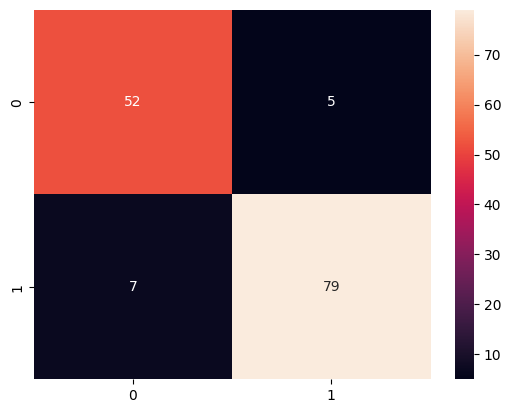

In [35]:
import seaborn as sns
sns.heatmap(cm, annot=True)